# Decoder Comparison

Compare all 6 spike-time decoders on a single trained model (tobj=0.875, seed=1).
Each decoder converts raw spike times to feature values in [0, 1] using a different strategy,
bthen we evaluate SVM classification accuracy on the resulting features.

In [1]:
import json
import os
os.chdir("../..")

import matplotlib.pyplot as plt
import numpy as np
import torch

from spiking import (
    BinaryFirstSpike,
    BinaryWindowFirstSpike,
    LinearInversion,
    NeuronMeanRelative,
    ScaledInversion,
    TargetRelative,
    evaluate_classifier,
    extract_spike_times,
    load_model,
)
from spiking.evaluation import plot_reduced_features
from applications.datasets import create_dataset

In [2]:
MODEL_DIR = "logs/mnist/threshold_research/tobj_0.875/seed_1"

model = load_model(os.path.join(MODEL_DIR, "model.pth"))

with open(os.path.join(MODEL_DIR, "setup.json")) as f:
    setup = json.load(f)
t_objective = setup["t_objective"]
print(f"t_objective: {t_objective}")

train_loader, test_loader = create_dataset("mnist")
shape = train_loader.dataset.image_shape
print(f"Image shape: {shape}")

t_objective: 0.875
Image shape: (28, 28)


In [3]:
spike_times_train, y_train = extract_spike_times(model, train_loader, shape)
spike_times_test, y_test = extract_spike_times(model, test_loader, shape)

finite_train = torch.isfinite(spike_times_train)
finite_test = torch.isfinite(spike_times_test)
print(f"Train: {spike_times_train.shape}, {finite_train.float().mean():.1%} finite spikes, mean={spike_times_train[finite_train].mean():.4f}")
print(f"Test:  {spike_times_test.shape}, {finite_test.float().mean():.1%} finite spikes, mean={spike_times_test[finite_test].mean():.4f}")

Train: torch.Size([60000, 256]), 18.4% finite spikes, mean=0.9474
Test:  torch.Size([10000, 256]), 18.7% finite spikes, mean=0.9468


In [4]:
# Per-neuron mean spike times (computed from train set, ignoring inf)
finite_mask = torch.isfinite(spike_times_train)
# Replace inf with nan so nanmean ignores them
spike_times_nan = spike_times_train.clone()
spike_times_nan[~finite_mask] = float("nan")
mean_spike_times = torch.nanmean(spike_times_nan, dim=0)
# Neurons that never spike: default to 1.0 (latest possible time)
mean_spike_times[torch.isnan(mean_spike_times)] = 1.0

decoders = {
    "BinaryFirstSpike": BinaryFirstSpike(),
    "BinaryWindowFirstSpike": BinaryWindowFirstSpike(tolerance=0.05),
    "LinearInversion": LinearInversion(),
    "ScaledInversion": ScaledInversion(),
    "TargetRelative": TargetRelative(t_target=t_objective),
    "NeuronMeanRelative": NeuronMeanRelative(mean_spike_times),
}
print(f"{len(decoders)} decoders ready")

6 decoders ready


In [5]:
results = {}
for name, decoder in decoders.items():
    X_train = decoder.decode(spike_times_train).numpy()
    X_test = decoder.decode(spike_times_test).numpy()
    train_metrics, val_metrics = evaluate_classifier(X_train, y_train.numpy(), X_test, y_test.numpy())
    results[name] = (train_metrics, val_metrics)
    print(f"{name:>20s}  train={train_metrics['accuracy']:.4f}  test={val_metrics['accuracy']:.4f}")

    BinaryFirstSpike  train=0.8412  test=0.8441
BinaryWindowFirstSpike  train=0.8933  test=0.8897
     LinearInversion  train=0.9334  test=0.9334
     ScaledInversion  train=0.9438  test=0.9424
      TargetRelative  train=0.9423  test=0.9398
  NeuronMeanRelative  train=0.9050  test=0.9022


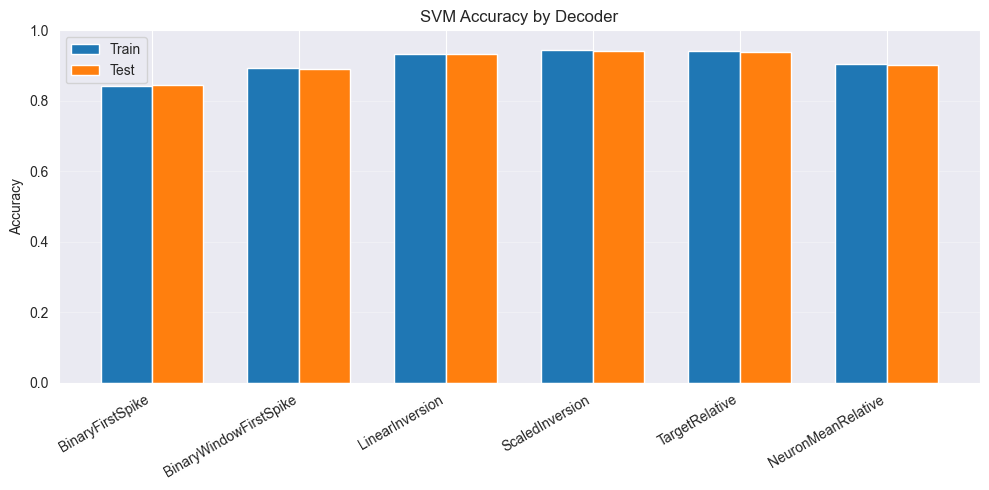

In [6]:
names = list(results.keys())
train_accs = [results[n][0]["accuracy"] for n in names]
test_accs = [results[n][1]["accuracy"] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, train_accs, width, label="Train")
ax.bar(x + width / 2, test_accs, width, label="Test")
ax.set_ylabel("Accuracy")
ax.set_title("SVM Accuracy by Decoder")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

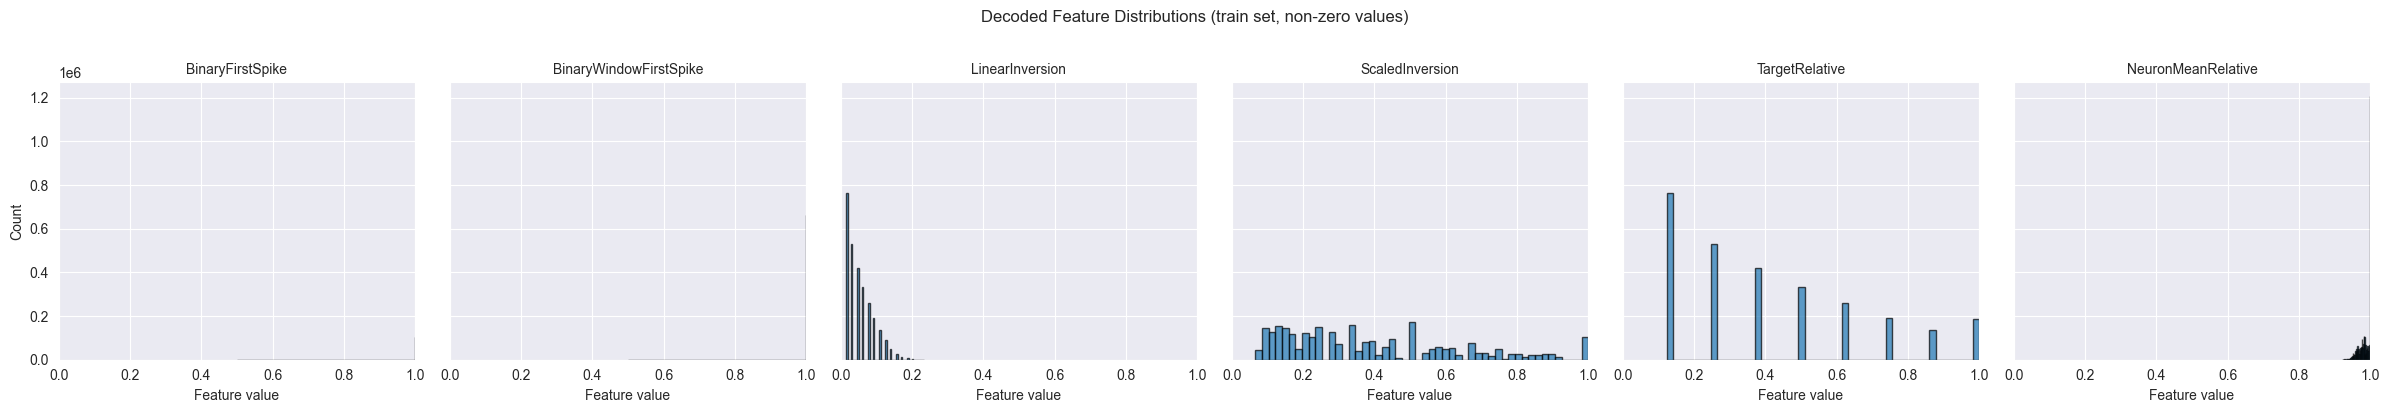

In [7]:
n_decoders = len(decoders)
fig, axes = plt.subplots(1, n_decoders, figsize=(4 * n_decoders, 4), sharey=True)
for ax, (name, decoder) in zip(axes, decoders.items()):
    features = decoder.decode(spike_times_train).numpy().ravel()
    # Only plot finite, non-zero features for readability
    finite_features = features[np.isfinite(features) & (features > 0)]
    ax.hist(finite_features, bins=50, edgecolor="black", alpha=0.7)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Feature value")
    ax.set_xlim(0, 1)
axes[0].set_ylabel("Count")
fig.suptitle("Decoded Feature Distributions (train set, non-zero values)", y=1.02)
plt.tight_layout()
plt.show()

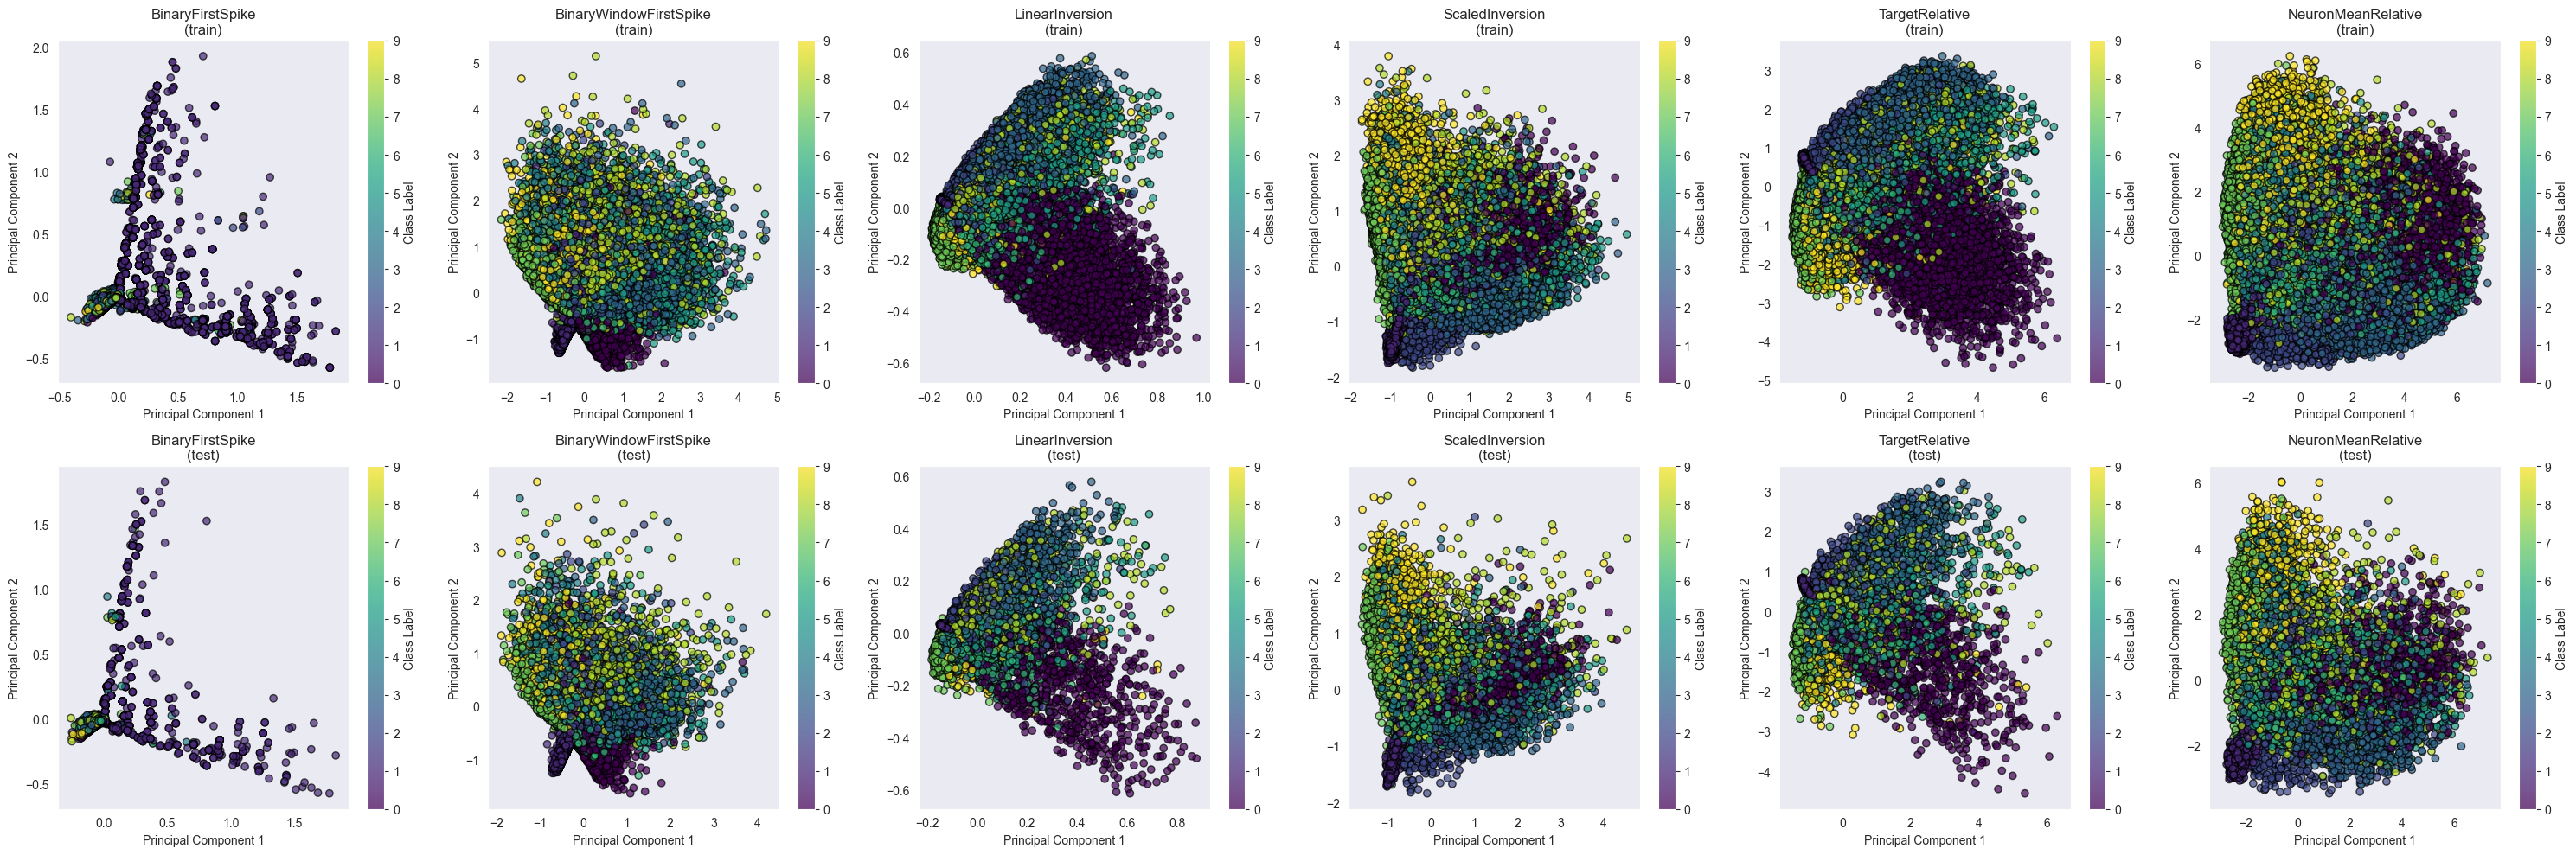

In [8]:
n_decoders = len(decoders)
fig, axes = plt.subplots(2, n_decoders, figsize=(5 * n_decoders, 10))

for col, (name, decoder) in enumerate(decoders.items()):
    X_train_dec = decoder.decode(spike_times_train).numpy()
    X_test_dec = decoder.decode(spike_times_test).numpy()

    plt.sca(axes[0, col])
    reducer = plot_reduced_features(X_train_dec, y_train.numpy(), f"{name}\n(train)")

    plt.sca(axes[1, col])
    plot_reduced_features(X_test_dec, y_test.numpy(), f"{name}\n(test)", reducer=reducer)

plt.tight_layout()
plt.show()